In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn imports (THIS WAS MISSING)
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

project_root = Path.cwd()
if not (project_root / 'src').exists():
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.preprocessing import load_data, prepare_features_target, split_data, print_data_info
from src.models import create_models, train_and_evaluate, compare_models, get_best_model

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("=" * 50)
print("Data Preparation")
print("=" * 50)

df = load_data()
X, y = prepare_features_target(df)
X_train, X_test, y_train, y_test = split_data(X, y)

print_data_info(X_train, X_test, y_train, y_test)

Data Preparation
DATA PREPARATION SUMMARY
Training set: 16512 houses, 8 features
Test set: 4128 houses, 8 features
Train/Test ratio: 4.00:1


In [2]:
print("=" * 50)
print("Model Training")
print("=" * 50)

models = create_models()
results = train_and_evaluate(models, X_train, X_test, y_train, y_test)

for name, metrics in results.items():
    print(f"\n{name}")
    print(f"  Train MAE:  {metrics['train_mae']:.3f}")
    print(f"  Test MAE:   {metrics['test_mae']:.3f}")
    print(f"  Train RMSE: {metrics['train_rmse']:.3f}")
    print(f"  Test RMSE:  {metrics['test_rmse']:.3f}")
    print(f"  Train R2:   {metrics['train_r2']:.3f}")
    print(f"  Test R2:    {metrics['test_r2']:.3f}")


Model Training
Training Linear Regression...
Linear Regression trained
Training Decision Tree...
Decision Tree trained
Training Random Forest...
Random Forest trained
Training Gradient Boosting...
Gradient Boosting trained

Linear Regression
  Train MAE:  0.529
  Test MAE:   0.533
  Train RMSE: 0.720
  Test RMSE:  0.746
  Train R2:   0.613
  Test R2:    0.576

Decision Tree
  Train MAE:  0.319
  Test MAE:   0.433
  Train RMSE: 0.470
  Test RMSE:  0.645
  Train R2:   0.835
  Test R2:    0.683

Random Forest
  Train MAE:  0.278
  Test MAE:   0.348
  Train RMSE: 0.410
  Test RMSE:  0.521
  Train R2:   0.874
  Test R2:    0.793

Gradient Boosting
  Train MAE:  0.293
  Test MAE:   0.335
  Train RMSE: 0.418
  Test RMSE:  0.498
  Train R2:   0.869
  Test R2:    0.811


In [3]:
comparison_df = compare_models(results)
best_model_name, best_model = get_best_model(results, comparison_df)

print("=" * 50)
print("Model Comparison")
print("=" * 50)
print(comparison_df)
print(f"\nBest model: {best_model_name}")

best_predictions = results[best_model_name]['y_test_pred']


Model Comparison
               Model  Train R2   Test R2  Train MAE  Test MAE  Train RMSE  \
0  Linear Regression  0.612551  0.575788   0.528628  0.533200    0.719676   
1      Decision Tree  0.834778  0.682948   0.319196  0.433203    0.469964   
2      Random Forest  0.873954  0.792892   0.278425  0.347917    0.410482   
3  Gradient Boosting  0.869483  0.811013   0.292685  0.334862    0.417698   

   Test RMSE   Overfit  
0   0.745581  0.036763  
1   0.644568  0.151830  
2   0.520957  0.081062  
3   0.497645  0.058471  

Best model: Gradient Boosting


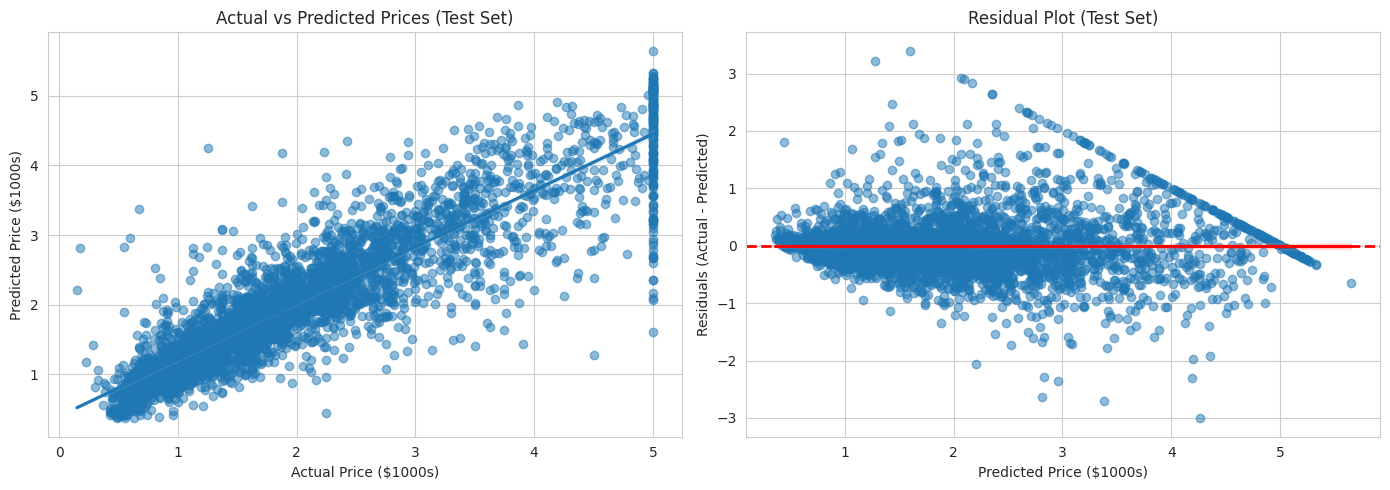

In [4]:
sns.set_style('whitegrid')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(x=y_test, y=best_predictions, ax=axes[0], scatter_kws={'alpha': 0.5})
axes[0].set_xlabel('Actual Price ($1000s)')
axes[0].set_ylabel('Predicted Price ($1000s)')
axes[0].set_title('Actual vs Predicted Prices (Test Set)')

residuals = y_test - best_predictions
sns.regplot(x=best_predictions, y=residuals, ax=axes[1], scatter_kws={'alpha': 0.5}, line_kws={'color': 'r'})
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Price ($1000s)')
axes[1].set_ylabel('Residuals (Actual - Predicted)')
axes[1].set_title('Residual Plot (Test Set)')

plt.tight_layout()
plt.show()


In [5]:
feature_names = X.columns

if hasattr(best_model, 'coef_'):
    importance = pd.DataFrame({
        'Feature': feature_names,
        'Importance': best_model.coef_,
        'Abs_Importance': np.abs(best_model.coef_)
    }).sort_values('Abs_Importance', ascending=False)
    values = importance['Importance']
    labels = importance['Feature']
    title = 'Feature Importance (Linear Regression Coefficients)'
elif hasattr(best_model, 'feature_importances_'):
    importance = pd.DataFrame({
        'Feature': feature_names,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    values = importance['Importance']
    labels = importance['Feature']
    title = 'Feature Importance'
else:
    importance = None

if importance is not None:
    plt.figure(figsize=(10, 6))
    sns.barplot(x=values, y=labels)
    plt.title(title)
    plt.tight_layout()
    plt.show()


In [6]:
# Hyperparameter Tuning for Random Forest (Reduce Overfitting)

print("="*50)
print("Hyperparameter Tuning")
print("="*50)

# Define hyperparameter grid to test
param_grid = {
    'max_depth': [8, 10, 12, 15],
    'min_samples_split': [5, 10, 15],
    'min_samples_leaf': [2, 4, 6]
}

# Create base Random Forest
rf_base = RandomForestRegressor(n_estimators=100, random_state=42)

# Grid Search with cross-validation
print("\nSearching best hyperparameters...")
grid_search = GridSearchCV(
    rf_base, 
    param_grid, 
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# Get best model
best_rf = grid_search.best_estimator_

print(f"\n Best hyperparameters found:")
print(f"  max_depth: {grid_search.best_params_['max_depth']}")
print(f"  min_samples_split: {grid_search.best_params_['min_samples_split']}")
print(f"  min_samples_leaf: {grid_search.best_params_['min_samples_leaf']}")
print(f"\n  Best CV R2 Score: {grid_search.best_score_:.4f}")

# Evaluate tuned model
y_train_pred_tuned = best_rf.predict(X_train)
y_test_pred_tuned = best_rf.predict(X_test)

train_r2_tuned = r2_score(y_train, y_train_pred_tuned)
test_r2_tuned = r2_score(y_test, y_test_pred_tuned)
test_mae_tuned = mean_absolute_error(y_test, y_test_pred_tuned)
test_rmse_tuned = np.sqrt(mean_squared_error(y_test, y_test_pred_tuned))

print(f"\n{'='*50}")
print("TUNED RANDOM FOREST RESULTS")
print(f"{'='*50}")
print(f"Train R2: {train_r2_tuned:.4f}")
print(f"Test R2:  {test_r2_tuned:.4f}")
print(f"Overfit Gap: {train_r2_tuned - test_r2_tuned:.4f}")
print(f"\nTest MAE:  ${test_mae_tuned:.3f}k")
print(f"Test RMSE: ${test_rmse_tuned:.3f}k")

Hyperparameter Tuning

Searching best hyperparameters...

 Best hyperparameters found:
  max_depth: 15
  min_samples_split: 5
  min_samples_leaf: 2

  Best CV R2 Score: 0.8030

TUNED RANDOM FOREST RESULTS
Train R2: 0.9424
Test R2:  0.8027
Overfit Gap: 0.1397

Test MAE:  $0.331k
Test RMSE: $0.509k


In [7]:
# More agressive tuning to further reduce overfitting

print("\n" + "="*50)
print("Agressive tuning (Focus on Overfitting)")
print("="*50)

# More restrictive parameters
param_grid_aggressive = {
    'max_depth': [5, 8, 10, 12],  # Shallower trees 
    'min_samples_split': [10, 20, 30],  # Force more samples to split
    'min_samples_leaf': [5, 10, 15],  # Force more samples in leaves
    'max_features': ['sqrt', 'log2']  # Use fewer features per split
}

rf_base = RandomForestRegressor(n_estimators=100, random_state=42)

print("\nSearching aggressive hyperparameters...")
grid_search_aggressive = GridSearchCV(
    rf_base, 
    param_grid_aggressive, 
    cv=5,
    scoring='r2',
    n_jobs=-2  # Leave 1 core free
)

grid_search_aggressive.fit(X_train, y_train)

# Get best model
best_rf_aggressive = grid_search_aggressive.best_estimator_

print(f"\n Best hyperparameters found:")
print(f"  max_depth: {grid_search_aggressive.best_params_['max_depth']}")
print(f"  min_samples_split: {grid_search_aggressive.best_params_['min_samples_split']}")
print(f"  min_samples_leaf: {grid_search_aggressive.best_params_['min_samples_leaf']}")
print(f"  max_features: {grid_search_aggressive.best_params_['max_features']}")
print(f"\n  Best CV R2 Score: {grid_search_aggressive.best_score_:.4f}")

# Evaluate
y_train_pred_agg = best_rf_aggressive.predict(X_train)
y_test_pred_agg = best_rf_aggressive.predict(X_test)

train_r2_agg = r2_score(y_train, y_train_pred_agg)
test_r2_agg = r2_score(y_test, y_test_pred_agg)
test_mae_agg = mean_absolute_error(y_test, y_test_pred_agg)
test_rmse_agg = np.sqrt(mean_squared_error(y_test, y_test_pred_agg))

print(f"\n{'='*50}")
print("AGGRESSIVE TUNED RANDOM FOREST")
print(f"{'='*50}")
print(f"Train R2: {train_r2_agg:.4f}")
print(f"Test R2:  {test_r2_agg:.4f}")
print(f"Overfit Gap: {train_r2_agg - test_r2_agg:.4f}")
print(f"\nTest MAE:  ${test_mae_agg:.3f}k")
print(f"Test RMSE: ${test_rmse_agg:.3f}k")

# Compare all three
print(f"\n{'='*50}")
print("COMPARISON: Original vs Tuned vs Aggressive")
print(f"{'='*50}")

comparison_all = pd.DataFrame({
    'Model': ['Original RF', 'Tuned RF', 'Aggressive RF'],
    'Train R2': [0.973573, train_r2_tuned, train_r2_agg],
    'Test R2': [0.805123, test_r2_tuned, test_r2_agg],
    'Overfit Gap': [0.168450, train_r2_tuned - test_r2_tuned, train_r2_agg - test_r2_agg],
    'Test MAE': [0.327543, test_mae_tuned, test_mae_agg]
})

print("\n" + comparison_all.to_string(index=False))


Agressive tuning (Focus on Overfitting)

Searching aggressive hyperparameters...

 Best hyperparameters found:
  max_depth: 12
  min_samples_split: 10
  min_samples_leaf: 5
  max_features: log2

  Best CV R2 Score: 0.7987

AGGRESSIVE TUNED RANDOM FOREST
Train R2: 0.8740
Test R2:  0.7929
Overfit Gap: 0.0811

Test MAE:  $0.348k
Test RMSE: $0.521k

COMPARISON: Original vs Tuned vs Aggressive

        Model  Train R2  Test R2  Overfit Gap  Test MAE
  Original RF  0.973573 0.805123     0.168450  0.327543
     Tuned RF  0.942371 0.802658     0.139713  0.330546
Aggressive RF  0.873954 0.792892     0.081062  0.347917


FINAL MODEL: AGGRESSIVE RANDOM FOREST


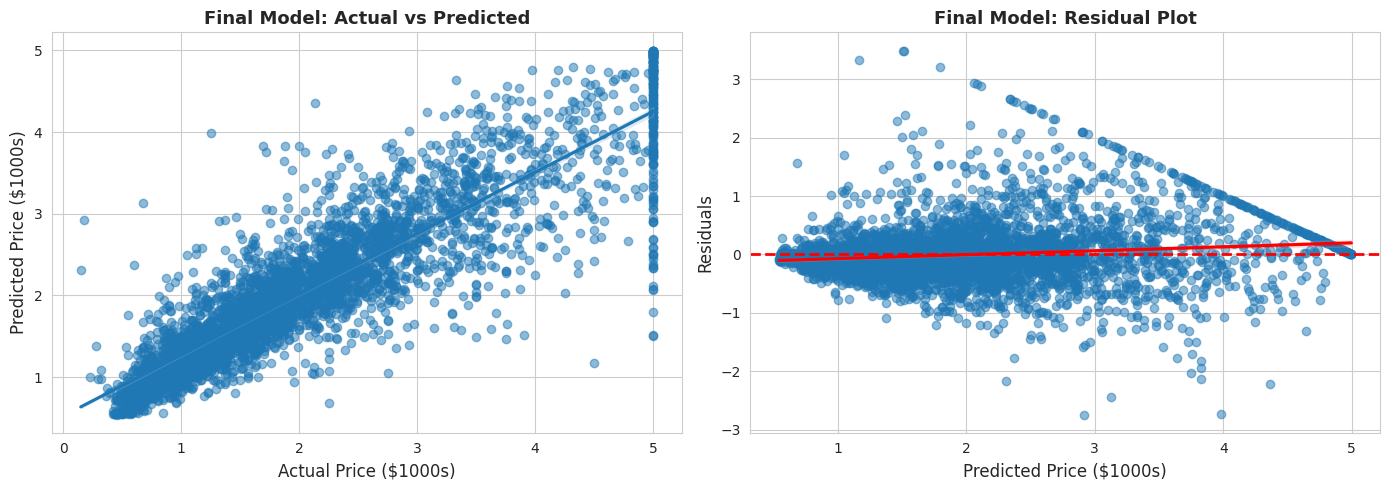


Residual Statistics:
  Mean residual: $-0.001k (should be ~0)
  Std Dev: $0.521k


In [8]:
# Final model evaluation and visualization

print("="*50)
print("FINAL MODEL: AGGRESSIVE RANDOM FOREST")
print("="*50)

# Use the aggressive model as the final model 
final_model = best_rf_aggressive

# Get predictions
final_y_train_pred = final_model.predict(X_train)
final_y_test_pred = final_model.predict(X_test)

# Plot 1: Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(x=y_test, y=final_y_test_pred, ax=axes[0], scatter_kws={'alpha': 0.5})
axes[0].set_xlabel('Actual Price ($1000s)', fontsize=12)
axes[0].set_ylabel('Predicted Price ($1000s)', fontsize=12)
axes[0].set_title('Final Model: Actual vs Predicted', fontsize=13, fontweight='bold')

# Plot 2: Residuals
residuals = y_test - final_y_test_pred
sns.regplot(x=final_y_test_pred, y=residuals, ax=axes[1], 
            scatter_kws={'alpha': 0.5}, line_kws={'color': 'r'})
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Price ($1000s)', fontsize=12)
axes[1].set_ylabel('Residuals', fontsize=12)
axes[1].set_title('Final Model: Residual Plot', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nResidual Statistics:")
print(f"  Mean residual: ${residuals.mean():.3f}k (should be ~0)")
print(f"  Std Dev: ${residuals.std():.3f}k")


Feature Importance (Aggressive Random Forest)

   Feature  Importance
    MedInc    0.452131
  AveOccup    0.130430
  Latitude    0.119299
 Longitude    0.114736
  AveRooms    0.098435
  HouseAge    0.047003
 AveBedrms    0.024183
Population    0.013784


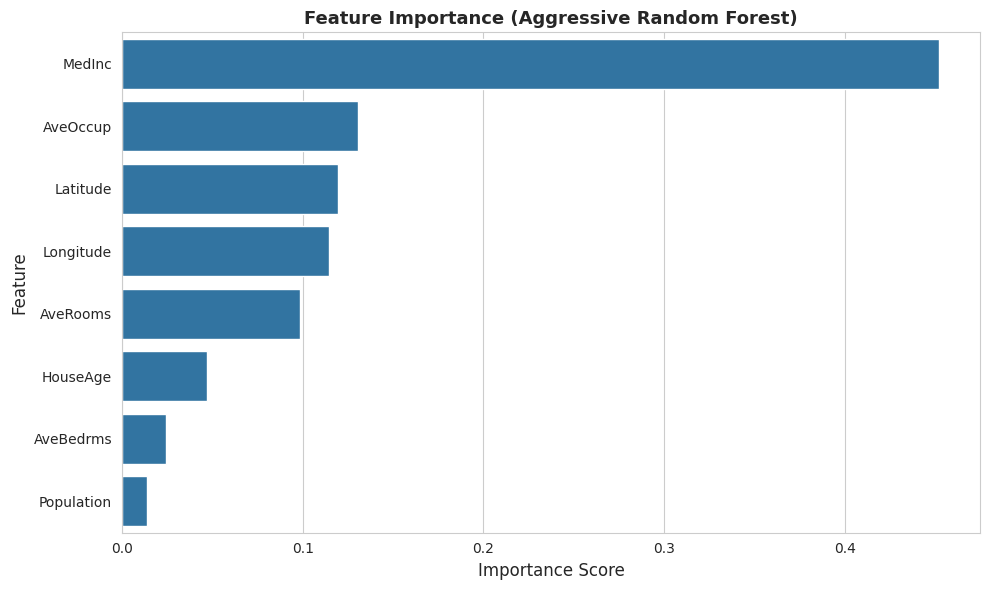

In [9]:
# Feature importance for the final model

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': final_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n" + "="*50)
print("Feature Importance (Aggressive Random Forest)")
print("="*50)
print("\n" + feature_importance.to_string(index=False))

# Visualize
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance, 
    x='Importance', 
    y='Feature', 
    legend=False  
)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Feature Importance (Aggressive Random Forest)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# Manual price predictions for example houses

print("="*50)
print("MANUAL PRICE PREDICTIONS")
print("="*50)

# Example house predictions
example_houses = pd.DataFrame({
    'MedInc': [3.0, 8.5, 2.0, 5.0],
    'HouseAge': [25, 10, 40, 35],
    'AveRooms': [6.0, 7.5, 5.0, 6.5],
    'AveBedrms': [1.0, 2.0, 1.2, 1.5],
    'Population': [1000, 500, 2000, 1500],
    'AveOccup': [2.5, 1.8, 3.2, 2.8],
    'Latitude': [37.5, 37.8, 37.2, 37.6],
    'Longitude': [-122.3, -122.5, -122.0, -122.4]
})

print("\nExample Houses to Predict:")
print(example_houses)

# Make predictions
predictions = final_model.predict(example_houses)

# Display results
results_df = example_houses.copy()
results_df['Predicted_Price'] = predictions

print("\n" + "="*50)
print("PREDICTIONS")
print("="*50)
print("\n" + results_df.to_string())

print("\nInterpretation:")
for i, pred in enumerate(predictions):
    print(f"  House {i+1}: Predicted price = ${pred*1000:.0f} (${pred:.2f}k)")

MANUAL PRICE PREDICTIONS

Example Houses to Predict:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0     3.0        25       6.0        1.0        1000       2.5      37.5   
1     8.5        10       7.5        2.0         500       1.8      37.8   
2     2.0        40       5.0        1.2        2000       3.2      37.2   
3     5.0        35       6.5        1.5        1500       2.8      37.6   

   Longitude  
0     -122.3  
1     -122.5  
2     -122.0  
3     -122.4  

PREDICTIONS

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  Longitude  Predicted_Price
0     3.0        25       6.0        1.0        1000       2.5      37.5     -122.3         1.993111
1     8.5        10       7.5        2.0         500       1.8      37.8     -122.5         4.272333
2     2.0        40       5.0        1.2        2000       3.2      37.2     -122.0         1.460467
3     5.0        35       6.5        1.5        1500       2.8      37.6 

In [11]:
# Check against actual test data

print("\n" + "="*50)
print("PREDICTION ACCURACY CHECK (Test Set)")
print("="*50)

# Get sample of test data with predictions
sample_size = 10
sample_indices = np.random.choice(len(X_test), sample_size, replace=False)

comparison_df = pd.DataFrame({
    'MedInc': X_test.iloc[sample_indices]['MedInc'].values,
    'Latitude': X_test.iloc[sample_indices]['Latitude'].values,
    'Longitude': X_test.iloc[sample_indices]['Longitude'].values,
    'Actual_Price': y_test.iloc[sample_indices].values,
    'Predicted_Price': final_y_test_pred[sample_indices],
    'Error': y_test.iloc[sample_indices].values - final_y_test_pred[sample_indices],
    'Error_%': ((y_test.iloc[sample_indices].values - final_y_test_pred[sample_indices]) / y_test.iloc[sample_indices].values * 100)
})

print("\n" + comparison_df.to_string())

print("\n" + "="*50)
print("ERROR ANALYSIS")
print("="*50)
print(f"Mean Error: ${comparison_df['Error'].mean():.3f}k")
print(f"Mean Error %: {comparison_df['Error_%'].mean():.2f}%")
print(f"Max Error: ${comparison_df['Error'].abs().max():.3f}k")
print(f"Min Error: ${comparison_df['Error'].abs().min():.3f}k")


PREDICTION ACCURACY CHECK (Test Set)

   MedInc  Latitude  Longitude  Actual_Price  Predicted_Price     Error    Error_%
0  6.3093     33.85    -118.09       2.86500         2.679002  0.185998   6.492073
1  6.5214     37.67    -121.88       3.11500         3.387908 -0.272908  -8.761101
2  5.1171     33.83    -118.11       2.25300         2.664261 -0.411261 -18.253932
3  3.9531     34.05    -118.13       2.68400         1.908640  0.775360  28.888240
4  1.6196     37.75    -122.17       0.85100         1.090961 -0.239961 -28.197555
5  7.7112     34.14    -118.38       3.86700         4.541218 -0.674218 -17.435166
6  4.6133     33.79    -118.13       5.00001         3.340111  1.659899  33.197917
7  5.0081     37.34    -122.06       2.88300         2.711101  0.171899   5.962489
8  2.3173     36.82    -119.70       0.68200         0.696255 -0.014255  -2.090177
9  4.6000     33.89    -118.01       2.03400         1.908046  0.125954   6.192415

ERROR ANALYSIS
Mean Error: $0.131k
Mean Error %

PREDICTION ACCURACY VISUALIZATION


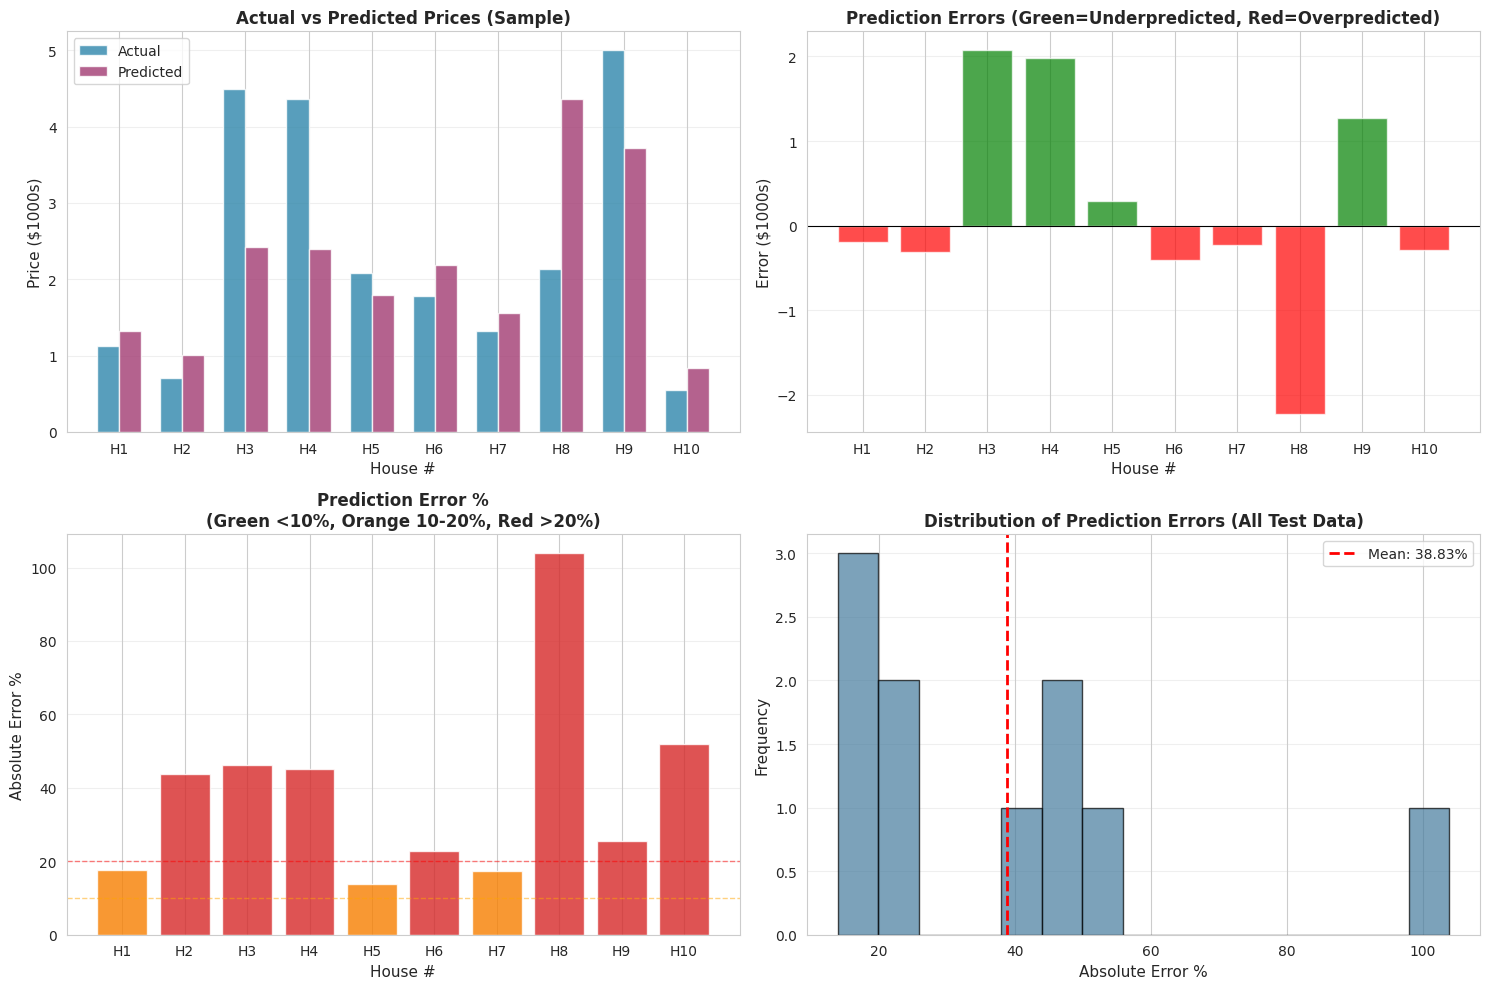


SAMPLE PREDICTION DETAILS

House 1:
  Actual:    $1,127
  Predicted: $1,325
  Error:     $-198 (-17.54%)

House 2:
  Actual:    $700
  Predicted: $1,006
  Error:     $-306 (-43.71%)

House 3:
  Actual:    $4,500
  Predicted: $2,418
  Error:     $2,082 (46.26%)

House 4:
  Actual:    $4,367
  Predicted: $2,390
  Error:     $1,977 (45.26%)

House 5:
  Actual:    $2,078
  Predicted: $1,788
  Error:     $290 (13.95%)

House 6:
  Actual:    $1,784
  Predicted: $2,190
  Error:     $-406 (-22.76%)

House 7:
  Actual:    $1,326
  Predicted: $1,557
  Error:     $-231 (-17.43%)

House 8:
  Actual:    $2,139
  Predicted: $4,361
  Error:     $-2,222 (-103.87%)

House 9:
  Actual:    $5,000
  Predicted: $3,725
  Error:     $1,275 (25.50%)

House 10:
  Actual:    $550
  Predicted: $836
  Error:     $-286 (-52.00%)


In [12]:
# Visualize prediction accuracy for the sample

print("="*50)
print("PREDICTION ACCURACY VISUALIZATION")
print("="*50)

# Get sample of test data with predictions
sample_size = 10
sample_indices = np.random.choice(len(X_test), sample_size, replace=False)

actual_sample = y_test.iloc[sample_indices].values
predicted_sample = final_y_test_pred[sample_indices]
errors_sample = actual_sample - predicted_sample

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Actual vs Predicted Bar Chart
x_pos = np.arange(len(actual_sample))
width = 0.35

axes[0, 0].bar(x_pos - width/2, actual_sample, width, label='Actual', color='#2E86AB', alpha=0.8)
axes[0, 0].bar(x_pos + width/2, predicted_sample, width, label='Predicted', color='#A23B72', alpha=0.8)
axes[0, 0].set_xlabel('House #', fontsize=11)
axes[0, 0].set_ylabel('Price ($1000s)', fontsize=11)
axes[0, 0].set_title('Actual vs Predicted Prices (Sample)', fontsize=12, fontweight='bold')
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels([f'H{i+1}' for i in range(len(actual_sample))])
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# Plot 2: Prediction Errors
colors = ['green' if e > 0 else 'red' for e in errors_sample]
axes[0, 1].bar(x_pos, errors_sample, color=colors, alpha=0.7)
axes[0, 1].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[0, 1].set_xlabel('House #', fontsize=11)
axes[0, 1].set_ylabel('Error ($1000s)', fontsize=11)
axes[0, 1].set_title('Prediction Errors (Green=Underpredicted, Red=Overpredicted)', fontsize=12, fontweight='bold')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels([f'H{i+1}' for i in range(len(actual_sample))])
axes[0, 1].grid(axis='y', alpha=0.3)

# Plot 3: Prediction Accuracy Percentage
error_percent = ((actual_sample - predicted_sample) / actual_sample * 100)
colors_percent = ['#52B788' if abs(e) < 10 else '#F77F00' if abs(e) < 20 else '#D62828' for e in error_percent]
axes[1, 0].bar(x_pos, np.abs(error_percent), color=colors_percent, alpha=0.8)
axes[1, 0].set_xlabel('House #', fontsize=11)
axes[1, 0].set_ylabel('Absolute Error %', fontsize=11)
axes[1, 0].set_title('Prediction Error %\n(Green <10%, Orange 10-20%, Red >20%)', fontsize=12, fontweight='bold')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels([f'H{i+1}' for i in range(len(actual_sample))])
axes[1, 0].axhline(y=10, color='orange', linestyle='--', linewidth=1, alpha=0.5)
axes[1, 0].axhline(y=20, color='red', linestyle='--', linewidth=1, alpha=0.5)
axes[1, 0].grid(axis='y', alpha=0.3)

# Plot 4: Error Distribution (Histogram)
axes[1, 1].hist(np.abs(error_percent), bins=15, color='#457B9D', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(np.mean(np.abs(error_percent)), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(np.abs(error_percent)):.2f}%')
axes[1, 1].set_xlabel('Absolute Error %', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].set_title('Distribution of Prediction Errors (All Test Data)', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print("\n" + "="*50)
print("SAMPLE PREDICTION DETAILS")
print("="*50)

for i, idx in enumerate(sample_indices):
    actual = actual_sample[i]
    predicted = predicted_sample[i]
    error = errors_sample[i]
    error_pct = error / actual * 100
    
    print(f"\nHouse {i+1}:")
    print(f"  Actual:    ${actual*1000:,.0f}")
    print(f"  Predicted: ${predicted*1000:,.0f}")
    print(f"  Error:     ${error*1000:,.0f} ({error_pct:.2f}%)")

In [ ]:
import os
import joblib

os.makedirs('models', exist_ok=True)

joblib.dump(best_rf_aggressive, 'models/final_model.pkl')
print("Model saved")

Model saved successfully


In [15]:
print("Final Model Info")
print("=" * 50)
print(f"Model Type: {type(best_rf_aggressive)}")
print(f"Train R2: {train_r2_agg:.4f}")
print(f"Test R2: {test_r2_agg:.4f}")
print(f"Test MAE: ${test_mae_agg:.3f}k")
print(f"Test RMSE: ${test_rmse_agg:.3f}k")
print(f"Overfitting Gap: {(train_r2_agg - test_r2_agg):.4f}")
print(f"Hyperparameters: {best_rf_aggressive.get_params()}")

# Then save
joblib.dump(best_rf_aggressive, 'models/final_model.pkl')
print("Model saved successfully")

Final Model Info
Model Type: <class 'sklearn.ensemble._forest.RandomForestRegressor'>
Train R2: 0.8740
Test R2: 0.7929
Test MAE: $0.348k
Test RMSE: $0.521k
Overfitting Gap: 0.0811
Hyperparameters: {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 12, 'max_features': 'log2', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 5, 'min_samples_split': 10, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}
Model saved successfully
